# Who lives alone, and can they pay?

**Business question:** Older adults who live alone are the people most likely to want one regular helper. Where do they live, and can they afford a weekly visit at my rate?

**Why it matters:** Notebooks 01 and 02 judged "can pay" by the income of all older households. People who live alone have one income, not two, so that may overstate what they can afford. This notebook checks.

**Data:** `data/census_by_zip.csv`, built by notebook 00 from the Census American Community Survey (ACS) 2020-2024.

**How to run:** Run the cells top to bottom. No Census key needed.

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 220)

DATA = "../data/census_by_zip.csv"
if not os.path.exists(DATA):
    raise FileNotFoundError("Run notebook 00_get_data first. It creates data/census_by_zip.csv.")
table = pd.read_csv(DATA, dtype={"zip": str}).set_index("zip")
print(table.shape[0], "ZIP code areas loaded")

24 ZIP code areas loaded


## 1. Settings you can change

A weekly visit is one 4-hour visit every week at &#36;35 an hour. The two income lines below are **my assumptions** about what a person living alone can afford. Change them and run again to see how the answer moves.

In [2]:
RATE, MIN_HOURS = 35, 4
yearly_cost = RATE * MIN_HOURS * 52      # one 4-hour visit every week for a year

COMFORTABLE_INCOME = 60000    # at or above this, a weekly visit is comfortable
OUT_OF_REACH_INCOME = 36000   # below this, a weekly visit is out of reach on income alone

print(f"One weekly visit costs about ${yearly_cost:,} a year.")
print(f"At ${COMFORTABLE_INCOME:,} a year that is {yearly_cost / COMFORTABLE_INCOME:.0%} of income; "
      f"at ${OUT_OF_REACH_INCOME:,} it is {yearly_cost / OUT_OF_REACH_INCOME:.0%}.")

One weekly visit costs about $7,280 a year.
At $60,000 a year that is 12% of income; at $36,000 it is 20%.


## 2. Count who lives alone and estimate their income

- **share_living_alone**: of older adults living at home (not in nursing homes), the share who live alone.
- **typical_income_alone**: the Census publishes a median income for men 65+ living alone and another for women. I combine the two, weighted by how many men and women live alone in each area. It is an approximation, not an official figure.
- **typical_income_all_65plus_households**: the median for every household headed by someone 65+, shown for comparison.
- **own_home_share**: share of older households that own their home. Owners may be able to pay from savings or home value even when income is low.

In [3]:
t = table[["area"]].copy()
t["live_alone"] = table["live_alone_65plus"]
t["women_share"] = table["live_alone_women_65plus"] / table["live_alone_65plus"]
at_home = table["residents_65plus"] - table["group_quarters_65plus"]   # leave out people in nursing homes
t["share_living_alone"] = t["live_alone"] / at_home

w, m = table["median_income_women_alone_65plus"], table["median_income_men_alone_65plus"]
nw, nm = table["live_alone_women_65plus"], table["live_alone_men_65plus"]
both = (w * nw + m * nm) / (nw + nm)
t["typical_income_alone"] = both.fillna(w).fillna(m)   # if one median is not published, use the other
t["typical_income_all_65plus_households"] = table["median_income_65plus_hh"]
t["visit_share_of_income"] = yearly_cost / t["typical_income_alone"]
t["own_home_share"] = table["owner_hh65"] / (table["owner_hh65"] + table["renter_hh65"])

def afford(income):
    if income >= COMFORTABLE_INCOME:
        return "Comfortable"
    if income >= OUT_OF_REACH_INCOME:
        return "A stretch"
    return "Out of reach"
t["weekly_visit"] = t["typical_income_alone"].apply(afford)
t = t.sort_values("live_alone", ascending=False)
t.round(2)

,area,live_alone,women_share,share_living_alone,typical_income_alone,typical_income_all_65plus_households,visit_share_of_income,own_home_share,weekly_visit
zip,,,,,,,,,
94501,"Alameda, main island",2860,0.72,0.28,38395.73,69740,0.19,0.58,A stretch
94611,"Oakland, Montclair / Piedmont",2810,0.69,0.33,51513.50,110769,0.14,0.70,A stretch
94610,"Oakland, Grand Lake",1855,0.62,0.34,60094.18,102315,0.12,0.58,Comfortable
94612,"Oakland, downtown",1796,0.60,0.57,14447.65,19241,0.50,0.10,Out of reach
94606,"Oakland, San Antonio / Eastlake",1564,0.56,0.30,14509.00,33565,0.50,0.34,Out of reach
94602,"Oakland, Glenview / Dimond",1459,0.64,0.25,61172.04,88351,0.12,0.72,Comfortable
94607,"Oakland, West Oakland / Chinatown",1355,0.58,0.36,17845.24,24362,0.41,0.37,Out of reach
94605,"Oakland, East Oakland hills",1353,0.58,0.19,34546.37,84621,0.21,0.82,Out of reach
94608,Emeryville / North Oakland,1266,0.52,0.36,45133.00,48580,0.16,0.52,A stretch


## 3. What the numbers say

In [4]:
total = t["live_alone"].sum()
print(f"{total:,.0f} people 65+ live alone across these areas. {table['live_alone_women_65plus'].sum() / total:.0%} are women.")
print(f"That is {total / at_home.sum():.0%} of older adults living at home.")
gap = (t["typical_income_alone"] / t["typical_income_all_65plus_households"]).median()
print(f"In a typical area, a person living alone has about {gap:.0%} of the income of the typical older household.\n")

GROUPS = ["Comfortable", "A stretch", "Out of reach"]
for label in GROUPS:
    rows = t[t["weekly_visit"] == label]
    print(f"{label}: {len(rows)} areas, {rows['live_alone'].sum():,.0f} people living alone ({rows['live_alone'].sum() / total:.0%})")
    for z, row in rows.iterrows():
        print(f"   {z}  {row['area']}: {row['live_alone']:,.0f} alone, typical income ${row['typical_income_alone']:,.0f}, "
              f"visit = {row['visit_share_of_income']:.0%} of income, {row['own_home_share']:.0%} own their home")
    print()

close = t[((t["typical_income_alone"] - COMFORTABLE_INCOME).abs() <= 3000) | ((t["typical_income_alone"] - OUT_OF_REACH_INCOME).abs() <= 3000)]
print("Close calls (within $3,000 of one of my income lines, so the label could go either way):")
for z, row in close.iterrows():
    print(f"   {z}  {row['area']}: ${row['typical_income_alone']:,.0f}")

owners = t[(t["weekly_visit"] == "Out of reach") & (t["own_home_share"] >= 0.75)]
print("\nLow income but mostly homeowners (may pay from savings or home value, or family may pay):")
for z, row in owners.iterrows():
    print(f"   {z}  {row['area']}: {row['own_home_share']:.0%} own their home")

28,995 people 65+ live alone across these areas. 64% are women.
That is 29% of older adults living at home.
In a typical area, a person living alone has about 59% of the income of the typical older household.

Comfortable: 10 areas, 9,077 people living alone (31%)
   94610  Oakland, Grand Lake: 1,855 alone, typical income $60,094, visit = 12% of income, 58% own their home
   94602  Oakland, Glenview / Dimond: 1,459 alone, typical income $61,172, visit = 12% of income, 72% own their home
   94618  Oakland, Rockridge: 1,255 alone, typical income $75,116, visit = 10% of income, 78% own their home
   94707  Berkeley, north hills: 832 alone, typical income $75,421, visit = 10% of income, 95% own their home
   94705  Berkeley, Claremont / Elmwood: 824 alone, typical income $73,881, visit = 10% of income, 83% own their home
   94708  Berkeley hills: 650 alone, typical income $88,360, visit = 8% of income, 92% own their home
   94709  Berkeley, north: 648 alone, typical income $61,156, visit =

## 4. Chart: the ten areas with the most older adults living alone

Each bar is the number of people 65+ who live alone. The bar color shows whether a weekly visit fits a typical income there. The column on the right gives that typical income.

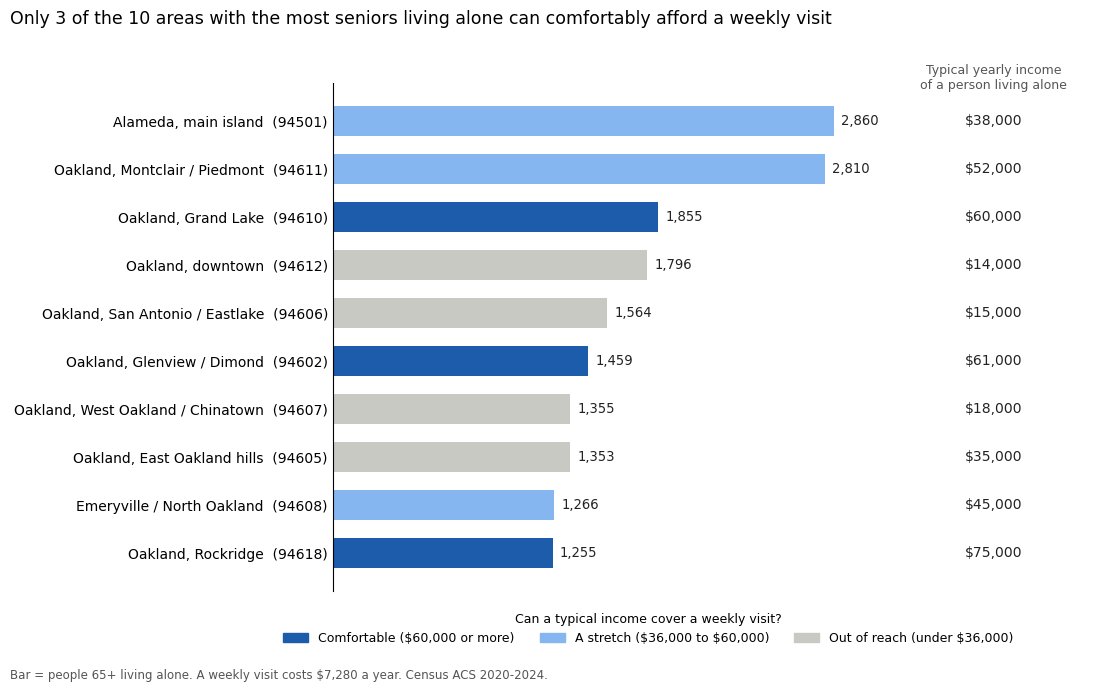

In [5]:
OUT = "../outputs"
os.makedirs(OUT, exist_ok=True)

show = t.head(10)
ypos = list(range(len(show)))[::-1]   # first row at the top
labels = [f"{row['area']}  ({z})" for z, row in show.iterrows()]
# One blue, dark to light, then gray: darker = easier to afford
colors = {"Comfortable": "#1c5cab", "A stretch": "#86b6ef", "Out of reach": "#c9c9c4"}

fig, ax = plt.subplots(figsize=(11, 0.45 * len(show) + 2.4))
ax.barh(ypos, show["live_alone"], color=[colors[v] for v in show["weekly_visit"]], height=0.62)
longest = show["live_alone"].max()
col_x = longest * 1.32
for y, (z, row) in zip(ypos, show.iterrows()):
    ax.text(row["live_alone"] + longest * 0.015, y, f"{row['live_alone']:,.0f}", va="center", fontsize=9.5, color="#222222")
    ax.text(col_x, y, f"\\${round(row['typical_income_alone'], -3):,.0f}", va="center", ha="center", fontsize=10, color="#222222")
ax.text(col_x, len(show) - 0.4, "Typical yearly income\nof a person living alone", va="bottom", ha="center", fontsize=9, color="#555555")
ax.set_yticks(ypos)
ax.set_yticklabels(labels, fontsize=10)
ax.set_xlim(0, longest * 1.5)
ax.set_xticks([])
ax.tick_params(axis="y", length=0)
for side in ["top", "right", "bottom"]:
    ax.spines[side].set_visible(False)
handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in colors.values()]
names = [f"Comfortable (\\${COMFORTABLE_INCOME:,} or more)",
         f"A stretch (\\${OUT_OF_REACH_INCOME:,} to \\${COMFORTABLE_INCOME:,})",
         f"Out of reach (under \\${OUT_OF_REACH_INCOME:,})"]
ax.legend(handles, names, title="Can a typical income cover a weekly visit?", loc="upper center",
          bbox_to_anchor=(0.42, -0.02), ncol=3, frameon=False, fontsize=9, title_fontsize=9)
n_ok = (show["weekly_visit"] == "Comfortable").sum()
fig.suptitle(f"Only {n_ok} of the 10 areas with the most seniors living alone can comfortably afford a weekly visit",
             x=0.01, ha="left", fontsize=12.5)
fig.text(0.01, 0.01, f"Bar = people 65+ living alone. A weekly visit costs \\${yearly_cost:,} a year. Census ACS 2020-2024.",
         fontsize=8.5, color="#555555")
plt.tight_layout(rect=(0, 0.03, 1, 0.97))
fig.savefig(f"{OUT}/living_alone.png", dpi=150)
t.round(3).to_csv(f"{OUT}/living_alone.csv")
plt.show()

## 5. What I decided

- **Where living alone and ability to pay line up:** Grand Lake, Glenview / Dimond and Rockridge among the larger areas, plus the smaller Berkeley hills areas.
- **Where the need is large but income is short:** Alameda's main island and Montclair / Piedmont, where a weekly visit is a stretch, and downtown Oakland, San Antonio / Eastlake and West Oakland / Chinatown, where it is out of reach on income alone.
- **What this changes about notebooks 01 and 02:** Household income overstates what people living alone can afford. I will offer a visit every other week as well as weekly. Later I want to look at assets and savings, not income alone.

### Limits to remember
- The two income lines are my assumptions. Section 3 lists the close calls.
- Income is not the whole picture. Homeowners may have savings or home value, and adult children often pay for a parent's help.
- The typical income is my blend of two published medians, and a median says nothing about the range. Every area has some people living alone who can pay and some who cannot.
- The Census does not publish income for people living alone in a few small ZIP codes; there I used the one median that was available.